### Import packages

In [1]:
import os, subprocess, pickle, warnings, logging, copy
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import healpy as hp
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from astropy.time import Time
from astropy.coordinates import SkyCoord, EarthLocation
from scipy.stats import norm
from scipy.optimize import curve_fit, root_scalar
from scipy.ndimage import gaussian_filter
from gammapy import __version__ as gammapy_version, __path__ as gammapy_path
from gammapy.irf import load_irf_dict_from_file
from gammapy.maps import MapAxis, WcsGeom, Map
from gammapy.modeling.models import (
    PointSpatialModel, PowerLawSpectralModel,
    ConstantTemporalModel, SkyModel, Models
)
from gammapy.data import DataStore, Observation, FixedPointingInfo, PointingMode
from gammapy.makers import MapDatasetMaker, SafeMaskMaker, RingBackgroundMaker
from gammapy.datasets import Dataset, Datasets, MapDataset, MapDatasetOnOff
from gammapy.estimators import ExcessMapEstimator, TSMapEstimator
from gammapy.estimators.map.excess import convolved_map_dataset_counts_statistics, _get_convolved_maps
from gammapy.stats.fit_statistics import cash

import utils, simulate, plotting

# --- Config ---
warnings.filterwarnings("ignore", category=RuntimeWarning, append=True)
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
warnings.filterwarnings("ignore", message=".*outside valid IRF map range.*")
logging.getLogger("gammapy").setLevel(logging.ERROR)
import ligo.skymap.plot
from ligo.skymap.io.fits import read_sky_map

# --- Setup ---
observing_location = EarthLocation.of_site("Roque de los Muchachos")
for path in ["./data/", "./data/tmp/", "./data/gw_input/", "./data/results/", "./data/slurm_output/"]:
    os.makedirs(path, exist_ok=True)

print(f"Using Gammapy version: {gammapy_version}\nIn path: {gammapy_path[0]}")

Using Gammapy version: 2.0.1
In path: /fefs/aswg/workspace/juan.jimenez/softs/conda/envs/gammapy-dev/lib/python3.13/site-packages/gammapy


##### <span style="color:blue">Main parameters</span>
* `source_name` Source name
* `dir_dl3` DL3 directory
* `e_min`, `e_max` and `e_bins`: Maximum, minimum energies and bins per decade
* `obs_id`: The run numbers to be used
* `bkg_type` If you want to use `baccmod` or `pybkgmodel`
* `e_min`, `e_max` and `e_bins`: Maximum, minimum offset, and total bins

In [37]:
source_name = "S240615dg"
source_coord = SkyCoord(ra=7.53, dec=45.81, unit="deg")

dir_dl3 = os.path.join(
    "/fefs/aswg/workspace/juan.jimenez/data/real", "mono", source_name, "v0.11.4", 
    "GammaDiffuse", "prod_standard", "DL3", "gh_dyn70"
)
obs_ids = [17822, 17823, 17824, 17825]

# Tool used for background computation
bkg_type = "baccmod" # baccmod or pybkgmodel

# Binning: energy and offset
e_min, e_max, e_bins = 0.15 * u.TeV, 0.6 * u.TeV, 4.5
o_min, o_max, o_bins = 0 * u.deg, 2.5 * u.deg, 5 # Offset binning
correlation_radius = 0.25 * u.deg

In [38]:
# source_name = "S240615dg"
# source_coord = SkyCoord(ra=7.53, dec=45.81, unit="deg")

# dir_dl3 = os.path.join(
#     "/fefs/aswg/workspace/juan.jimenez/data/real", "stereo", source_name, "v0.6.1", 
#     "GammaDiffuse", "prod_standard", "DL3", "gh_dyn90"
# )

# obs_ids = [17821, 17822, 17823, 17824, 17825]

# # Tool used for background computation
# bkg_type = "pybkgmodel" # baccmod or pybkgmodel

# # Binning: energy and offset
# e_min, e_max, e_bins = 0.6 * u.TeV, 20 * u.TeV, 4.5
# o_min, o_max, o_bins = 0 * u.deg, 2.5 * u.deg, 8 # Offset binning
# correlation_radius = 0.1 * u.deg

Other secundary parameters

In [75]:
# --- Flags ---
USE_DIRAC_DELTA   = False
USE_ITERATIVE_ULS = False
OVERWRITE_RESULTS = False

# --- Grid & Energy Geometry ---
binsz                 = 0.02
resolution_hp_to_grid = 2048         # HEALPix → grid resolution
size_fov              = 2.5  * u.deg
geom_width            = (size_fov.value * 1.43,) * 2
e_t_min, e_t_max, e_t_bins = 0.05 * u.TeV, 100 * u.TeV, 6
ring_r_in, ring_width = 0.3  * u.deg, 0.2 * u.deg
exclusion_mask = None

# --- Source & Skymap ---
delta_coord = SkyCoord(ra=7.53, dec=45.81, unit="deg")
confidence_level = 0.95
n_sim_bkg, n_sim_flux = 5000,1000
threshold_percent_gw = np.flip(np.sort([0.95, 0.5]))  # GW probability contours
file_ligo = f"./data/gw_input/{source_name}.fits"

### <span style="color:blue">Reading GW data</span>

In [76]:
# %%time
# # --- Grid ---
# ra_bins  = np.linspace(-180, 180, resolution_hp_to_grid)
# dec_bins = np.linspace( -90,   90, resolution_hp_to_grid)
# ra_grid, dec_grid = np.deg2rad(np.meshgrid(ra_bins, dec_bins))

# # --- GW Map ---
# data_ligo_hp, meta_ligo_hp = read_sky_map(file_ligo)
# if USE_DIRAC_DELTA:
#     nside        = hp.get_nside(data_ligo_hp)
#     data_ligo_hp = utils.make_dirac_delta_hp(delta_coord, nside)
#     data_ligo_2d = utils.make_dirac_delta_2d(delta_coord, ra_bins, dec_bins)
# else:
#     data_ligo_2d = utils.healpix2map(data_ligo_hp, ra_bins, dec_bins)
# data_ligo_2d_smooth = gaussian_filter(data_ligo_2d, sigma=2)

# # --- Contours & Hotspot ---
# threshold_maps = None if USE_DIRAC_DELTA else utils.get_hp_map_thresholds(data_ligo_hp, threshold_percent_gw)
# hotspot_coord  = utils.get_2d_map_hotspot(data_ligo_2d, ra_bins, dec_bins)

### Defining the geometry (FoV, Energy axis, Spatial Binning)

Energy axis edges:


<Quantity [0.15      , 0.23811016, 0.37797631, 0.6       ] TeV>

Offset axis edges:


<Quantity [0. , 0.5, 1. , 1.5, 2. , 2.5] deg>

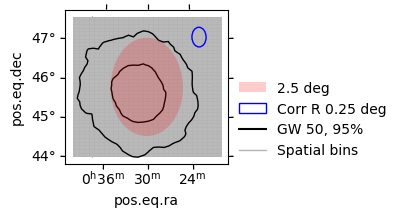

In [77]:
# --- Axes ---
axis_offset      = MapAxis.from_bounds(o_min, o_max, nbin=o_bins, name="offset")
axis_energy      = MapAxis.from_energy_bounds(e_min,   e_max,   nbin=e_bins, per_decade=True, name="energy")
axis_energy_true = MapAxis.from_energy_bounds(e_t_min, e_t_max, nbin=e_bins, per_decade=True, name="energy_true")
print("Energy axis edges:"); display(axis_energy.edges)
print("Offset axis edges:"); display(axis_offset.edges)

# --- Geometry ---
npix = (int(geom_width[0] / binsz), int(geom_width[1] / binsz))
geom = WcsGeom.create(
    skydir=(source_coord.ra.degree, source_coord.dec.degree),
    npix=npix, binsz=binsz, width=geom_width, frame="icrs", proj="AIR", axes=[axis_energy],
)
geom_image = geom.to_image()

# --- Coords ---
bin_c_ra, bin_c_dec, bin_edges_ra, bin_edges_dec, \
bin_area, coord_array, coord_center, separations_map = utils.extract_geom_coords(geom)

# --- Plot ---
plotting.summary_geometry(geom, bin_edges_ra, bin_edges_dec, size_fov, data_ligo_2d, threshold_maps, correlation_radius)

### <span style="color:blue">Converting the GW information into the WCS geometry</span>

Geometry covers 98.91% of the GW


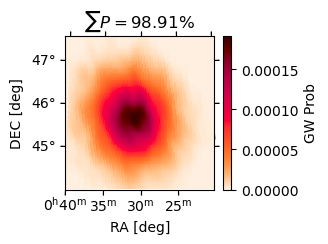

CPU times: user 27 s, sys: 12.4 s, total: 39.4 s
Wall time: 39.3 s


In [79]:
%%time
# --- HEALPix Setup ---
pix_indices, nside = np.arange(len(data_ligo_hp)), hp.npix2nside(len(data_ligo_hp))
dec_hp, ra_hp      = utils.IndexToDeclRa(pix_indices, nside)
hp_area            = hp.nside2pixarea(nside)

# --- GW Probability on WCS ---
if USE_DIRAC_DELTA:
    prob_gw_integrated, num_hp_pixels = utils.integrate_dirac_delta_on_wcs(
        data_ligo_hp, dec_hp, ra_hp, bin_edges_ra, bin_edges_dec)
else:
    prob_gw_integrated, num_hp_pixels = utils.integrate_hp_on_wcs(
        data_ligo_hp, dec_hp, ra_hp, hp_area, bin_edges_ra, bin_edges_dec, bin_area)

norm_factor_gammapy_region = np.sum(prob_gw_integrated.ravel())
print(f"Geometry covers {norm_factor_gammapy_region * 100:.2f}% of the GW")

prob_gw = np.clip(prob_gw_integrated, a_min=1e-20, a_max=np.inf)
log_gw  = 2 * np.log(prob_gw)

# --- Threshold Masks ---
masks_thresholds = utils.compute_threshold_masks(
    threshold_maps, ra_grid, dec_grid, data_ligo_2d, bin_c_ra, bin_c_dec, prob_gw_integrated
) if threshold_maps is not None else [prob_gw_integrated == 1.0]
mask_threshold_95 = masks_thresholds[0]

# --- Plot ---
plotting.summary_gw_map(geom, bin_edges_ra, bin_edges_dec, prob_gw)

### Reading the DL3 data and adding BKG hdu

In [80]:
# --- Load Data Store ---
data_store_real = DataStore.from_dir(dir_dl3)
print(f"Obs IDs in directory: {data_store_real.obs_ids}\n")

# --- Add Background IRF ---
data_store_real.hdu_table.remove_rows(data_store_real.hdu_table["HDU_TYPE"] == "bkg")  # avoid duplicates on re-run
for obs_id in obs_ids:
    data_store_real = utils.add_bkg(data_store_real, obs_id, dir_dl3, dim_bkg=3, bkg_type=bkg_type)
data_store_real.hdu_table = data_store_real.hdu_table.copy()

# --- Observations ---
obs_collection_real = data_store_real.get_observations(obs_id=obs_ids, required_irf=["aeff", "edisp", "psf"])
obs_table = data_store_real.obs_table[np.isin(data_store_real.obs_table["OBS_ID"], obs_ids)]
hdu_table = data_store_real.hdu_table[np.isin(data_store_real.hdu_table["OBS_ID"], obs_ids)]

print(f"Total livetime: {obs_table['LIVETIME'].to(u.min).sum():.2f}\n")
display(obs_table); display(hdu_table)

Obs IDs in directory: [17820 17821 17822 17823 17824 17825]

Total livetime: 76.13 min



OBS_ID,DATE-OBS,TIME-OBS,DATE-END,TIME-END,RA_PNT,DEC_PNT,ZEN_PNT,ALT_PNT,AZ_PNT,RA_OBJ,DEC_OBJ,TSTART,TSTOP,ONTIME,TELAPSE,LIVETIME,DEADC,OBJECT,OBS_MODE,N_TELS,TELLIST,INSTRUME
,,,,,deg,deg,deg,deg,deg,deg,deg,s,s,s,s,s,,,,,,
int64,bytes10,bytes12,bytes10,bytes12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bytes9,bytes8,int64,bytes5,bytes5
17822,2024-06-16,03:17:59.537,2024-06-16,03:38:01.082,7.493825891282605,46.212115403792225,55.2632696091618,34.7367303908382,51.40397554281095,7.69,45.67,180155879.53714827,180157081.08229947,1195.7269394397736,1201.5451512038708,1134.9183227454248,0.9491450642377941,S240615dg,POINTING,1,LST-1,LST-1
17823,2024-06-16,03:38:23.488,2024-06-16,03:58:23.832,7.4971551933661935,45.41107040873675,51.83976977704598,38.16023022295402,52.81797753468018,7.69,45.67,180157103.4876945,180158303.83224896,1200.323659658432,1200.3445544540882,1143.2194559120799,0.9524259950332047,S240615dg,POINTING,1,LST-1,LST-1
17824,2024-06-16,03:58:43.650,2024-06-16,04:18:48.660,8.073213229364793,45.80868850408393,48.72668281576751,41.27331718423249,52.47482929072374,7.69,45.67,180158323.649524,180159528.65955472,1205.0278496742249,1205.0100307166576,1148.9473744213078,0.9534612621043752,S240615dg,POINTING,1,LST-1,LST-1
17825,2024-06-16,04:19:11.787,2024-06-16,04:39:00.371,6.92848138815696,45.80766648350139,44.41920051067039,45.58079948932961,52.31826504432189,7.69,45.67,180159551.78711033,180160740.37080288,1188.5843360424042,1188.5836925506592,1140.4502493735395,0.9595030110954218,S240615dg,POINTING,1,LST-1,LST-1


OBS_ID,HDU_TYPE,HDU_CLASS,FILE_DIR,FILE_NAME,HDU_NAME,SIZE
int64,bytes8,bytes9,bytes1,bytes25,bytes17,int64
17822,events,events,.,dl3_LST-1.Run17822.fits,EVENTS,13466880
17822,gti,gti,.,dl3_LST-1.Run17822.fits,GTI,13466880
17822,pointing,pointing,.,dl3_LST-1.Run17822.fits,POINTING,13466880
17822,aeff,aeff_2d,.,dl3_LST-1.Run17822.fits,EFFECTIVE AREA,13466880
17822,edisp,edisp_2d,.,dl3_LST-1.Run17822.fits,ENERGY DISPERSION,13466880
17822,psf,psf_table,.,dl3_LST-1.Run17822.fits,PSF,13466880
17823,events,events,.,dl3_LST-1.Run17823.fits,EVENTS,20796480
17823,gti,gti,.,dl3_LST-1.Run17823.fits,GTI,20796480
17823,pointing,pointing,.,dl3_LST-1.Run17823.fits,POINTING,20796480


#### Showing summaries for all the data + IRFs inside the DL3

EVENTS SUMMARY:


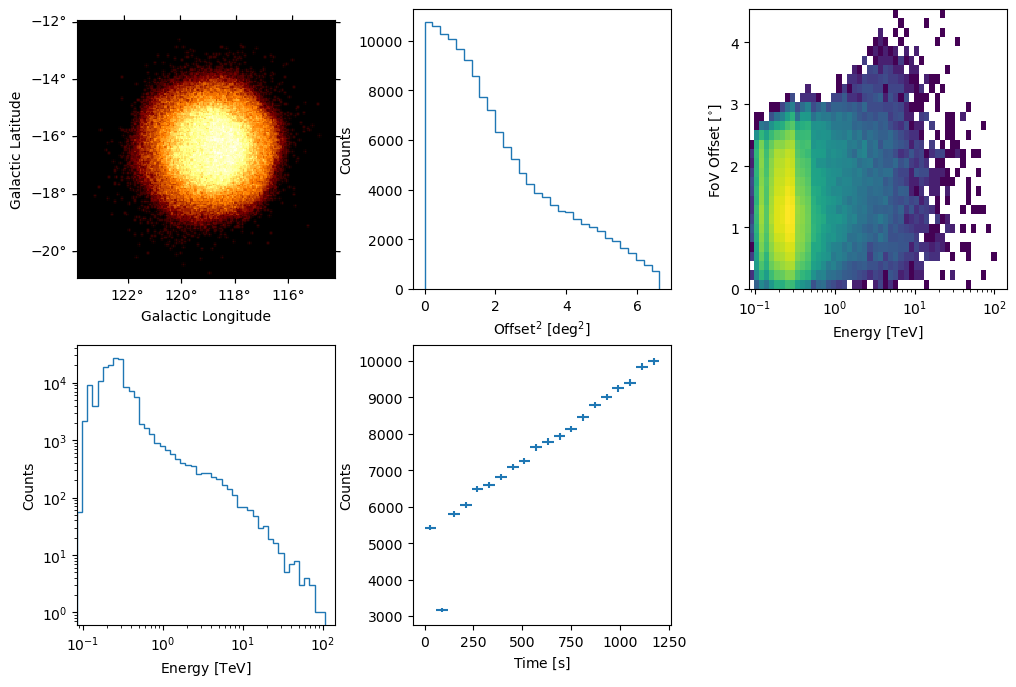

EFFECTIVE AREA SUMMARY:


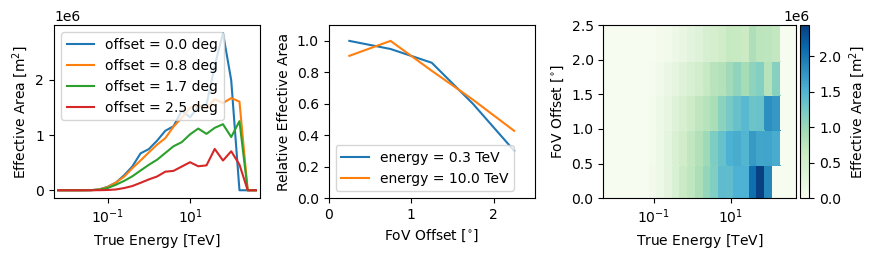

ENERGY DISPERSION SUMMARY:


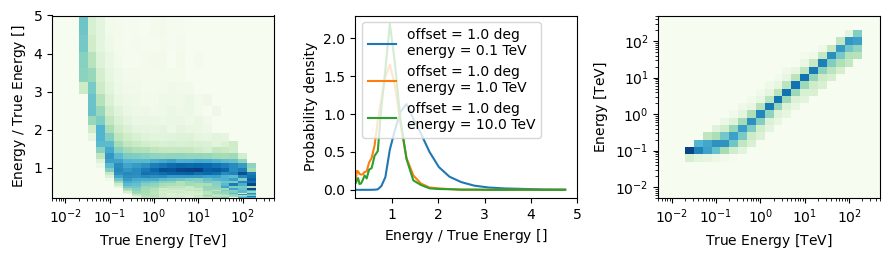

PSF SUMMARY:


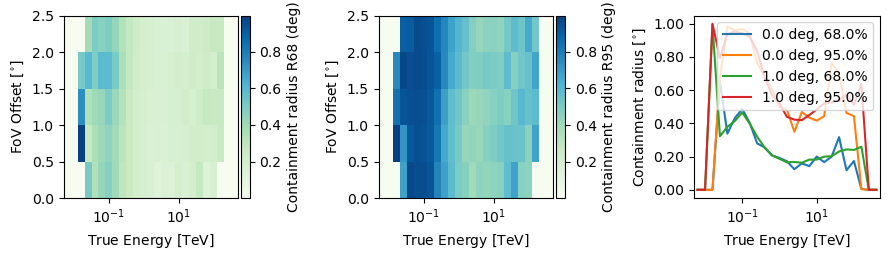

BACKGROUND SUMMARY:


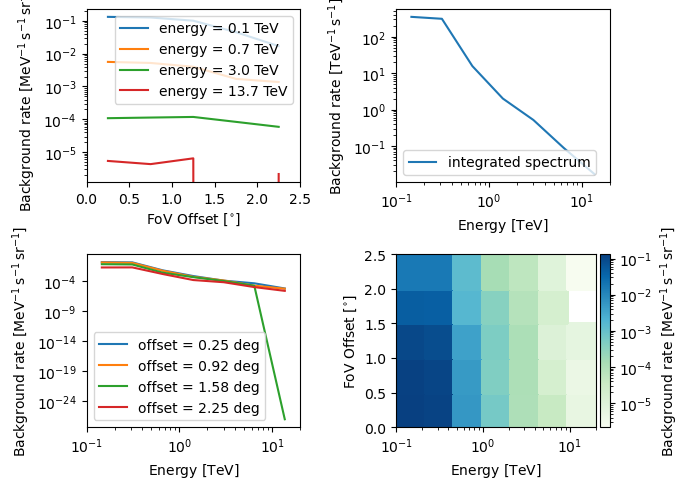

In [81]:
obs = obs_collection_real[0]
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)
    print("EVENTS SUMMARY:"); obs.events.peek(); plt.show()
    print("EFFECTIVE AREA SUMMARY:"); obs.aeff.peek(figsize=(9, 2.7)); plt.show()
    print("ENERGY DISPERSION SUMMARY:"); obs.edisp.peek(figsize=(9, 2.7)); plt.show()
    print("PSF SUMMARY:"); obs.psf.peek(figsize=(9, 2.7)); plt.show()
    print("BACKGROUND SUMMARY:"); obs.bkg.peek(figsize=(7, 5)); plt.show()

#### We run the pipeline for the real data to compare

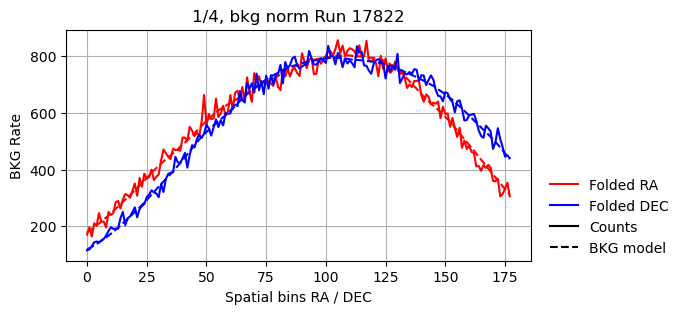

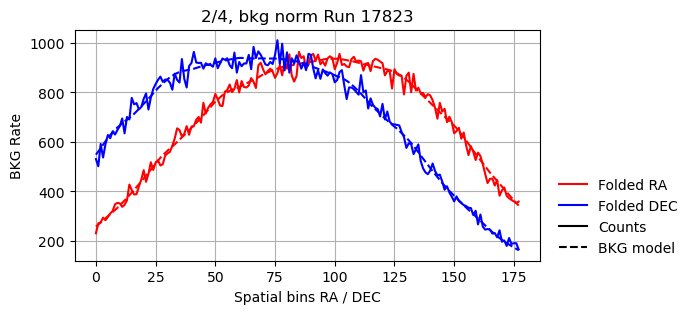

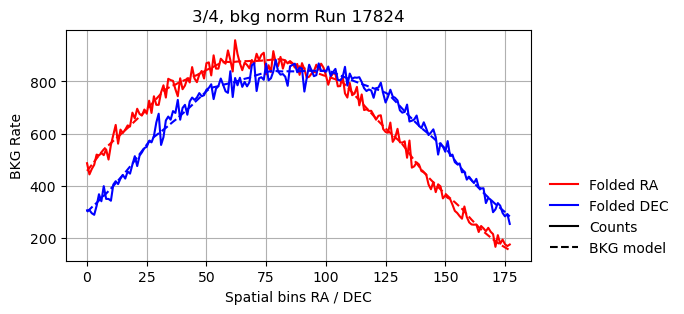

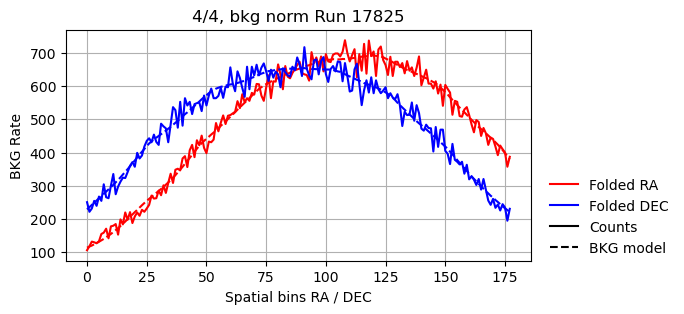

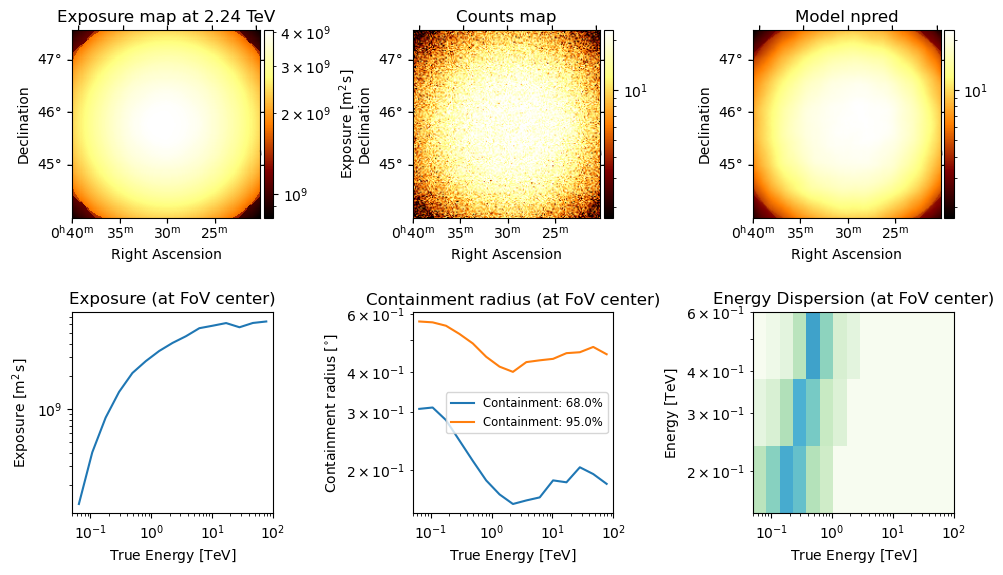

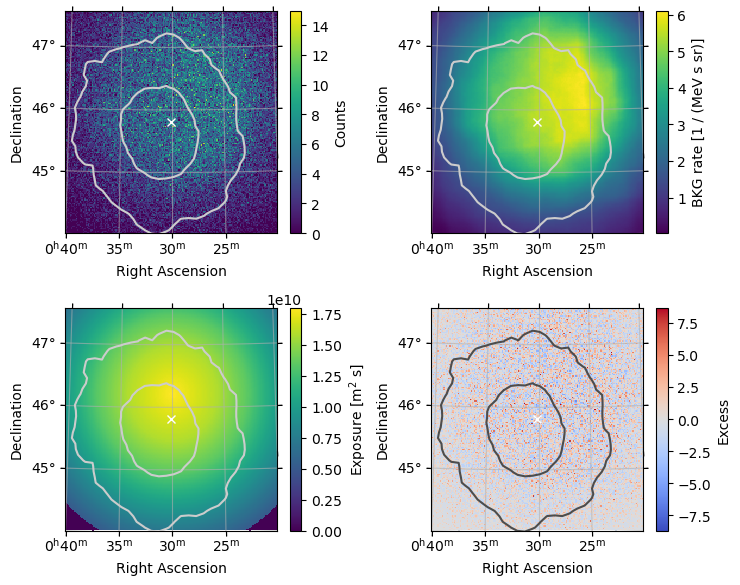

In [82]:
# --- Makers ---
maker = MapDatasetMaker(selection=["counts", "background", "psf", "edisp", "exposure"])
maker_safe_mask = SafeMaskMaker(methods=["offset-max"], offset_max=size_fov)
maker_ring = RingBackgroundMaker(r_in=ring_r_in, width=ring_width, exclusion_mask=exclusion_mask)

# --- Empty Datasets ---
dataset_empty = MapDataset.create(geom, energy_axis_true=axis_energy_true)
dataset_stacked_real = MapDataset.create(geom, energy_axis_true=axis_energy_true)

# --- Processing Loop ---
dataset_real, bkg_models = [], []
for i, obs in enumerate(obs_collection_real):
    dataset    = maker.run(dataset_empty.copy(), obs)
    dataset    = maker_safe_mask.run(dataset, obs)
    dataset_on_off = maker_ring.run(dataset)

    bkg_models.append(dataset_on_off.background.copy())
    dataset_real.append(dataset_on_off)
    dataset_stacked_real.stack(dataset_on_off)

    plotting.summary_folded_counts(dataset_on_off, bin_c_ra, obs, i, len(obs_collection_real))

datasets_all_real = Datasets(dataset_real)

# --- Summary Plots ---
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)
    dataset_stacked_real.peek(figsize=(10, 6))
plotting.summary_maps(
    dataset_real[0], geom, bin_edges_ra, bin_edges_dec,
    data_ligo_2d, threshold_maps, source_coord, source_name
)

### Defining the estimators needed
* `ExcessMapEstimator`: We use it for TS computation as is faster, and less complex. It uses a TopHat smearing for convolving the reco maps.
* `TSMapEstimator`: We use it for Flux computation. It takes more time but uses the full PSF for convolution of maps.

In [83]:
# --- Shared Config ---
energy_edges = [axis_energy.edges[0], axis_energy.edges[-1]]
n_sigma_ul   = norm.ppf(confidence_level)

spatial_model  = PointSpatialModel(lon_0=source_coord.ra, lat_0=source_coord.dec)
spectral_model = PowerLawSpectralModel(index=2)

# --- Estimators ---
excess_estimator = ExcessMapEstimator(
    correlation_radius    = correlation_radius,
    correlate_off         = True,
    spectral_model        = spectral_model,
    energy_edges          = energy_edges,
    sum_over_energy_groups= True,
    selection_optional    = ["ul"],
)
excess_estimator.n_sigma_ul = n_sigma_ul

ts_estimator = TSMapEstimator(
    model                 = SkyModel(spectral_model=PowerLawSpectralModel(),
                                     spatial_model=spatial_model),
    energy_edges          = energy_edges,
    sum_over_energy_groups= True,
    selection_optional    = ["ul"],
)
ts_estimator.n_sigma_ul = n_sigma_ul

### Computing $ \Lambda$ for the real data

Instead of computing the UL (just for following same procedure in the simulations) we first compute the "stats", that is much faster. This include TS and the related quantities.

We compute our main parameter $\Lambda$, that is defined as the maximum TS' in the 95% region.

In [84]:
stats_real = convolved_map_dataset_counts_statistics(
    convolved_maps = _get_convolved_maps(
        dataset = dataset_stacked_real, 
        kernel = excess_estimator.estimate_kernel(dataset_stacked_real), 
        mask = excess_estimator.estimate_mask_default(dataset_stacked_real), 
        correlate_off = excess_estimator.correlate_off
    ),
    stat_type = "cash" # "wstat" or "cash", cash works with OnOffMapDataset
)

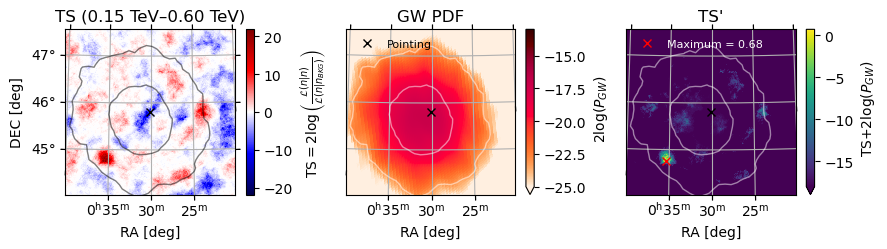

In [85]:
# --- Cash Statistics ---
n_on   = stats_real.n_on.sum(axis=0)
mu_bkg = stats_real.mu_bkg.sum(axis=0)

lik_alt  = cash(n_on, n_on)
lik_null = cash(n_on, mu_bkg)
ts_sign  = np.where((n_on - mu_bkg) >= 0.0, +1.0, -1.0)
ts       = np.where((lik_null - lik_alt) < 0.0, 0.0, lik_null - lik_alt) * ts_sign
ts2      = ts + 2 * np.log(prob_gw)

# --- GW-Weighted Maximum (95% region) ---
ts2_masked        = np.where(mask_threshold_95, ts2, np.nan)
ts2_argmax        = np.unravel_index(np.nanargmax(ts2_masked), ts2_masked.shape)
lambda_real       = np.nanmax(ts2_masked)
lambda_coord_real = SkyCoord(ra=bin_c_ra[ts2_argmax], dec=bin_c_dec[ts2_argmax], unit=u.deg, frame="icrs")

plotting.summary_ts_maps(
    geom, bin_c_ra, bin_c_dec, ts, log_gw, ts2, data_ligo_2d, threshold_maps, source_coord,
    lambda_real, lambda_coord_real, axis_energy
)

### Getting IRFs, pointing, and timing information from real data
Main goal is taking the `Datasets()` object of real data, and extract all the information:
* IRFs
* Livetime
* Starting time
* Pointings 

Then we have this empty object that we can use to do our simulations repeatedly.

#### Filling the `Observation` object with the extracted data

### We create a empty unique dataset for the observations

Only thing left is set the `model` and then simulate the events `.fake()` later.


Run 17822
 - IRFs:     ['aeff', 'edisp', 'psf', 'bkg']
 - Livetime: 18.92 min
 - Time Ref: 2024-06-16 03:17:59.537
 - Pointing: (RA=7.49, DEC=46.21) deg

Run 17823
 - IRFs:     ['aeff', 'edisp', 'psf', 'bkg']
 - Livetime: 19.05 min
 - Time Ref: 2024-06-16 03:38:23.488
 - Pointing: (RA=7.50, DEC=45.41) deg

Run 17824
 - IRFs:     ['aeff', 'edisp', 'psf', 'bkg']
 - Livetime: 19.15 min
 - Time Ref: 2024-06-16 03:58:43.650
 - Pointing: (RA=8.07, DEC=45.81) deg

Run 17825
 - IRFs:     ['aeff', 'edisp', 'psf', 'bkg']
 - Livetime: 19.01 min
 - Time Ref: 2024-06-16 04:19:11.787
 - Pointing: (RA=6.93, DEC=45.81) deg


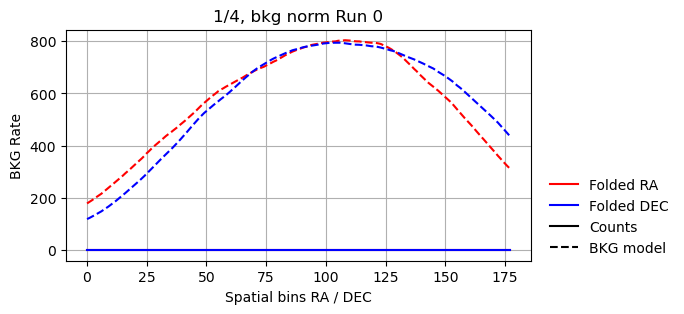

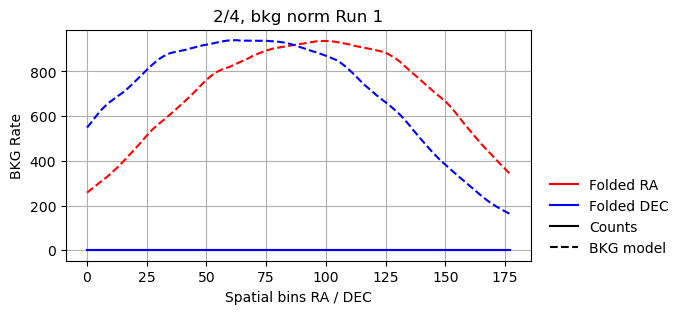

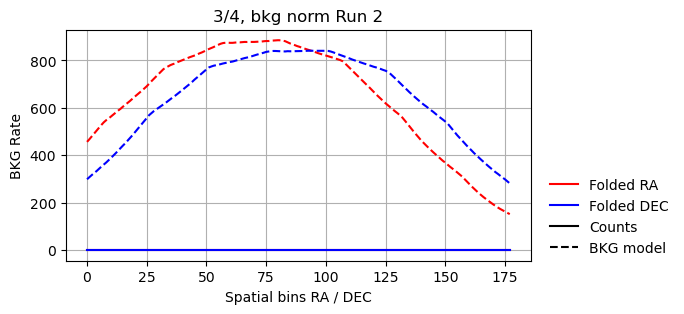

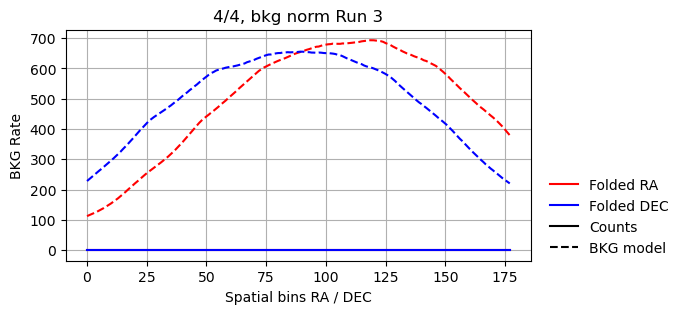

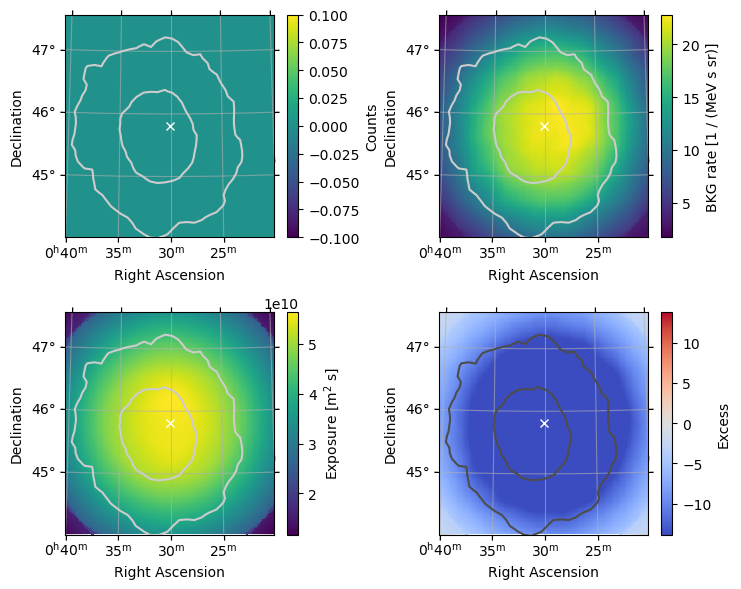

In [86]:
# --- Load IRFs per Observation ---
obs_irfs, obs_time_ref, obs_pointing, obs_livetime = [], [], [], []
for obs_id in obs_ids:
    hdu_tab = data_store_real.hdu_table[data_store_real.hdu_table["OBS_ID"] == obs_id]
    obs_tab = data_store_real.obs_table[data_store_real.obs_table["OBS_ID"] == obs_id]

    path_dl3 = os.path.join(dir_dl3, hdu_tab[hdu_tab["HDU_NAME"] == "EVENTS"]["FILE_NAME"][0])
    path_bkg = os.path.join(dir_dl3, hdu_tab[hdu_tab["HDU_NAME"] == "BACKGROUND"]["FILE_NAME"][0])

    irfs = load_irf_dict_from_file(path_dl3)
    irfs.update(load_irf_dict_from_file(path_bkg))
    obs_irfs.append(irfs)

    t_ref  = Time(f"{obs_tab['DATE-OBS'][0]} {obs_tab['TIME-OBS'][0]}", scale="utc")
    pnt    = SkyCoord(ra=obs_tab["RA_PNT"][0], dec=obs_tab["DEC_PNT"][0], unit=u.deg, frame="icrs")
    t_live = np.sum(obs_tab["LIVETIME"])
    obs_time_ref.append(t_ref);  obs_pointing.append(pnt);  obs_livetime.append(t_live)

    print(f"\nRun {obs_id}"
          f"\n - IRFs:     {list(irfs.keys())}"
          f"\n - Livetime: {t_live/60:.2f} min"
          f"\n - Time Ref: {t_ref}"
          f"\n - Pointing: (RA={obs_tab['RA_PNT'][0]:.2f}, DEC={obs_tab['DEC_PNT'][0]:.2f}) deg")

# --- Build Observations ---
observations = [
    Observation.create(
        obs_id         = f"{i}",
        pointing       = FixedPointingInfo(obs_pointing[i]),
        livetime       = obs_livetime[i] * u.s,
        irfs           = obs_irfs[i],
        location       = observing_location,
        reference_time = obs_time_ref[i],
    ) for i in range(len(obs_irfs))
]

# --- Simulate Datasets ---
maker = MapDatasetMaker(selection=["background", "psf", "edisp", "exposure"])
maker_safe_mask = SafeMaskMaker(methods=["offset-max"], offset_max=size_fov)
dataset_empty = MapDataset.create(geom, energy_axis_true=axis_energy_true)
dataset_stacked_simulated = MapDataset.create(geom, energy_axis_true=axis_energy_true)

dataset_simulated = []
for i, obs in enumerate(observations):
    dataset = maker_safe_mask.run(maker.run(dataset_empty.copy(), obs), obs)
    dataset.background = bkg_models[i]
    dataset_simulated.append(dataset)
    dataset_stacked_simulated.stack(dataset)
    plotting.summary_folded_counts(dataset, bin_c_ra, obs, i, len(observations))

dataset_all_simulated = Datasets(dataset_simulated)
plotting.summary_maps(
    dataset_stacked_simulated, geom, bin_edges_ra, bin_edges_dec,
    data_ligo_2d, threshold_maps, source_coord, source_name
)

### Computing correction factor for `ExcessMapEstimator`

Test amplitude 1.0e-08 cm-2 s-1 TeV-1 @ 1 TeV — 100/100

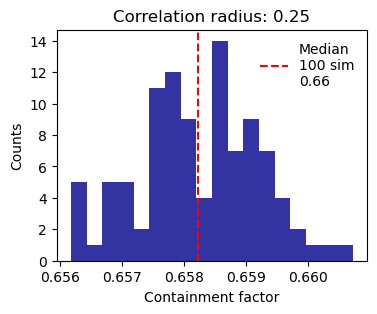

CPU times: user 1min 1s, sys: 2.33 s, total: 1min 3s
Wall time: 1min 3s


In [87]:
%%time
# --- Source Model ---
nsim_test     = 100
test_amplitud = 1e-8  # cm-2 s-1 TeV-1 @ 1 TeV
model_source  = Models([SkyModel(
    spatial_model  = PointSpatialModel.from_position(coord_center),
    spectral_model = PowerLawSpectralModel(index=2, amplitude=f"{test_amplitud} cm-2 s-1 TeV-1", reference="1 TeV"),
    temporal_model = ConstantTemporalModel(),
    name           = "model-simulated-test",
)])
true_flux_int = model_source[0].spectral_model.integral(
    excess_estimator.energy_edges[0], excess_estimator.energy_edges[-1]
)

# --- Containment Loop ---
containment_fluxes_test = []
for k in range(nsim_test):
    dataset_test = copy.deepcopy(dataset_stacked_simulated)
    dataset_test.models = model_source
    dataset_test.fake()
    dataset_test.models = None
    print(f"Test amplitude {test_amplitud:.1e} cm-2 s-1 TeV-1 @ 1 TeV — {k+1}/{nsim_test}", end="\r")

    result_test    = excess_estimator.run(dataset=dataset_test)
    central_index  = (0, len(result_test.flux.data[0][0])//2, len(result_test.flux.data[0].T[0])//2)
    containment_fluxes_test.append(result_test.flux.data[central_index] / (u.cm**2) / u.s / true_flux_int)

# --- Plot ---
containment_factor = np.median(containment_fluxes_test)
fig, ax = plt.subplots(figsize=(4, 3))
ax.hist(containment_fluxes_test, 18, color="darkblue", alpha=0.8)
ax.axvline(containment_factor, color="r", ls="--", label=f"Median\n{nsim_test} sim\n{containment_factor:.2f}")
ax.set(xlabel="Containment factor", ylabel="Counts", title=f"Correlation radius: {correlation_radius.value}")
ax.legend(frameon=False)
plt.show()

### Computting the Sky-Map ULs for real data
We compute the flux SkyMap using `ExcessEstimator`. The estimator that uses the top-hat kernel, so we need to correct those values for the containment of flux that we computed based on simulations.

In [88]:
# --- Excess Map ---
print("Running Excess Map Estimator...")
maps_real = excess_estimator.run(dataset_stacked_real)

# --- Flux Arrays ---
def _masked(arr): return np.where(mask_threshold_95, arr, np.nan)
def _masked_array(*arrays):
    """Return compressed arrays containing only pixels where mask_threshold_95 is True and no NaNs."""
    flat_mask = mask_threshold_95.ravel()
    results = []
    for arr in arrays:
        flat = arr.ravel()
        valid = flat_mask & ~np.isnan(flat)
        results.append(flat[valid])
    return np.array(results)
    
flux_uls  = maps_real["flux_ul"].data.ravel() / containment_factor
fluxs     = maps_real["flux"].data.ravel()    / containment_factor
flux_uls_95 = _masked(maps_real["flux_ul"].data).ravel() / containment_factor
fluxs_95    = _masked(maps_real["flux"].data).ravel()    / containment_factor

sigs = maps_real["sqrt_ts"].data.ravel()
sigs_95 = _masked_array(maps_real["sqrt_ts"].data).ravel()

Running Excess Map Estimator...


## Testing flux distributions

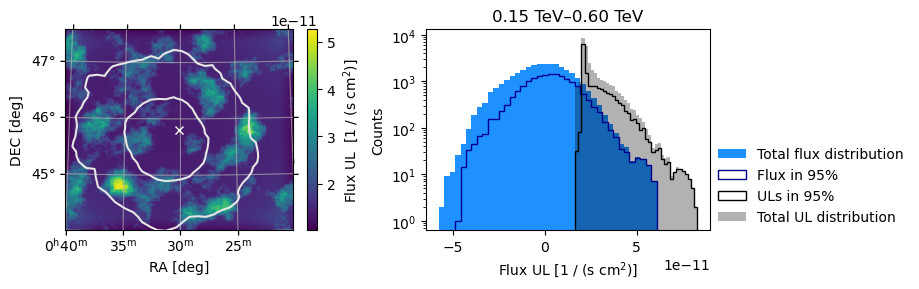

In [89]:
fig = plt.figure(figsize=(9.3, 3))
ax1 = plt.subplot(121, projection=geom.wcs)
ax2 = plt.subplot(122)

p_sig = ax1.pcolormesh(
    bin_edges_ra, bin_edges_dec, maps_real["flux_ul"].smooth(0.5).data[0],
    cmap="viridis", transform=ax1.get_transform("icrs")
); fig.colorbar(p_sig, ax=ax1, label="Flux UL  [1 / (s cm$^2$)]")

ax1.plot(source_coord.ra, source_coord.dec, "xw", label=source_name, transform=ax1.get_transform("icrs"))

h = ax2.hist(fluxs, 40, histtype="stepfilled", color="dodgerblue", label="Total flux distribution")
ax2.hist(fluxs_95, h[1], histtype="step", color="darkblue", label="Flux in 95%")

h = ax2.hist(flux_uls_95, 40, histtype="step", color="k", label="ULs in 95%")
ax2.hist(flux_uls, h[1], histtype="stepfilled", color="k", alpha=0.3, label="Total UL distribution")


lims = ax1.get_xlim(), ax1.get_ylim()
ax1.contour(data_ligo_2d, levels=threshold_maps, transform=ax1.get_transform("icrs"),
           colors="0.9", origin="lower", extent=[-180, 180, -90, 90])
ax1.set_xlim(*lims[0]); ax1.set_ylim(*lims[1]); ax1.grid(alpha=0.7)
ax2.set(xlabel="Flux UL [1 / (s cm$^2$)]", ylabel="Counts", yscale="log")
ax2.set_title(f"{energy_edges[0]:.2f}–{energy_edges[1]:.2f}")
ax1.coords[0].set_axislabel_position("b"); ax1.coords[0].set_ticklabel_position("b")
ax1.coords[0].set_axislabel("RA [deg]"); ax1.coords[1].set_axislabel("DEC [deg]")
ax2.legend(loc=(1.01, 0), frameon=False)
fig.tight_layout()
plt.show()

### Test of TS distribution

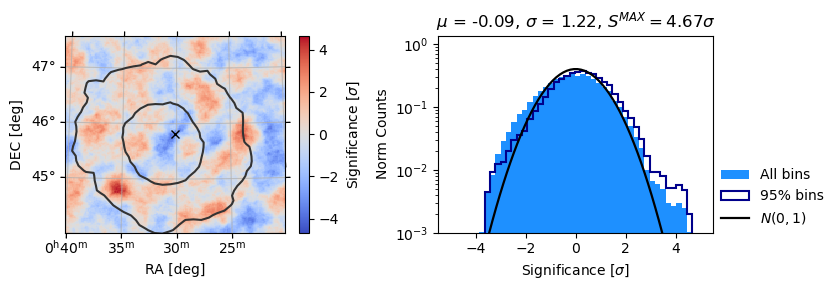

In [90]:
# Fitting to a normal distribution ---
mu_fit, std_fit = norm.fit(sigs)
mu_fit_95, std_fit_95 = norm.fit(sigs_95)
x_pdf = np.linspace(-7, 7, 100)
pdf_fit = norm.pdf(x_pdf, mu_fit, std_fit)
pdf_fit_95 = norm.pdf(x_pdf, mu_fit_95, std_fit_95)
pdf_norm = norm.pdf(x_pdf, 0, 1)
max_sig, min_sig = np.array(maps_real["sqrt_ts"].data).max(), -np.array(maps_real["sqrt_ts"].data).max()

# Plotting ---
fig = plt.figure(figsize=(8.5, 3))
ax1 = plt.subplot(121, projection=geom.wcs)
ax2 = plt.subplot(122)

p_sig = ax1.pcolormesh(
    bin_edges_ra, bin_edges_dec, maps_real["sqrt_ts"].smooth(0.5).data[0],
    cmap="coolwarm", transform=ax1.get_transform("icrs"), vmax=max_sig, vmin=min_sig
); fig.colorbar(p_sig, ax=ax1, label="Significance [$\\sigma$]")

ax1.plot(source_coord.ra, source_coord.dec, "xk", label=source_name, transform=ax1.get_transform("icrs"))

h = ax2.hist(sigs, 40, density=True, color="dodgerblue", lw=0, histtype="stepfilled", label="All bins")
ax2.hist(sigs_95, h[1], density=True, color="darkblue", lw=1.5, histtype="step", label="95% bins")

# ax2.plot(x_pdf, pdf_fit, lw=1.6, ls=":", color="b")
# ax2.plot(x_pdf, pdf_fit_95, lw=1.6, ls=":", color="r")
# ax2.plot([], [], lw=1.6, ls=":", color="k", label="$N$-fit")
ax2.plot(x_pdf, pdf_norm, lw=1.6, ls="-", color="k", label="$N(0, 1)$")


lims = ax1.get_xlim(), ax1.get_ylim()
ax1.contour(data_ligo_2d, levels=threshold_maps, transform=ax1.get_transform("icrs"),
           colors="0.2", origin="lower", extent=[-180, 180, -90, 90])
ax1.set_xlim(*lims[0]); ax1.set_ylim(*lims[1]); ax1.grid(alpha=0.7)
ax2.set(yscale="log", ylim=(1e-3), xlim=(-5.5, 5.5), xlabel="Significance [$\\sigma$]", ylabel="Norm Counts")
ax2.set_title(f"$\\mu$ = {mu_fit:.2f}, $\\sigma$ = {std_fit:.2f}, " + "$S^{MAX} = $"+f"{sigs.max():.2f}" + "$\\sigma$")
ax1.coords[0].set_axislabel_position("b"); ax1.coords[0].set_ticklabel_position("b")
ax1.coords[0].set_axislabel("RA [deg]"); ax1.coords[1].set_axislabel("DEC [deg]")
ax2.legend(loc=(1.01, 0), frameon=False)
fig.tight_layout()
plt.show()

### Defining the needed input parameters in the simulations

In order to perform the simulations we store the relevant information into a `.pkl` file:
* The ExcessMapEstimator
* The empty dataset to be simulated (all runs contained)
* The GW SkyMap converted into WCS map
* The mask of the Map for the 95% region
* The containment factor for the flux

In [94]:
type_obs = "mono" if "mono" in dir_dl3.lower() else "stereo" if "stereo" in dir_dl3.lower() else "unknown"

_pkl_base = dict(
    excess_estimator   = excess_estimator,
    ts_estimator       = ts_estimator,
    prob_gw            = prob_gw,
    data_ligo_hp       = data_ligo_hp,
    mask_threshold_95  = mask_threshold_95,
    containment_factor = containment_factor,
    e_min              = e_min,
    e_max              = e_max,
    type_obs           = type_obs,
    source_name        = source_name,
    # flux_uls = flux_uls,
    # maps_real = maps_real,
    # dataset = dataset_stacked_real,
)
_pkl_stem = os.path.join(
    "data", "tmp", (
        f"{source_name}_{type_obs}_E{e_min.value}_{e_max.value}_bkg{bkg_type}_corr{correlation_radius.value}" + 
        f"{'_isdirac' if USE_DIRAC_DELTA else ''}_binsize{binsz}"
))

path_pkl = f"{_pkl_stem}.pkl" # simulated dataset (used downstream)
path_pkl_real = f"{_pkl_stem}_real.pkl" # real dataset

for path, dataset in [(path_pkl, dataset_stacked_simulated), (path_pkl_real, dataset_stacked_real)]:
    with open(path, "wb") as f:
        pickle.dump({**_pkl_base, "dataset": dataset}, f)

# Launching the BKG simulations

In [20]:
%%time
# --- Config ---
compute_uls   = False
amplitude_bkg = 0.0

_stem = (
    f"{source_name}_{type_obs}_E{e_min.value}_{e_max.value}_bkg{bkg_type}_corr{correlation_radius.value}" + 
    f"{'_isdirac' if USE_DIRAC_DELTA else ''}_binsize{binsz}"
)
_ext  = "extended" if compute_uls else ""
path_results_bkg = os.path.join("data", "results", f"{_stem}_N_{n_sim_bkg}_f_{amplitude_bkg}_{_ext}.npz")

# --- Simulate or Load ---
if not os.path.exists(path_results_bkg) or OVERWRITE_RESULTS:
    simulate.perform_n_simulations(
        n_sim       = n_sim_bkg,
        amplitude   = amplitude_bkg,
        file_input  = path_pkl,
        file_output = path_results_bkg,
        compute_uls = compute_uls,
    )
else:
    print("Data already exists")

# --- Load Results ---
print(f"\nLoading for N={n_sim_bkg}...\n")
data_bkg = np.load(path_results_bkg, allow_pickle=True)

lambda_bkg, lambda_ra_bkg, lambda_dec_bkg = data_bkg["lambda_data"], data_bkg["lambda_ra"],  data_bkg["lambda_dec"]
tsmax_bkg, tsmax_ra_bkg, tsmax_dec_bkg    = data_bkg["tsmax"], data_bkg["tsmax_ra"], data_bkg["tsmax_dec"]
f_ra_bkg, f_dec_bkg = data_bkg["f_ra"], data_bkg["f_dec"]
ts_dist, ts2_dist   = data_bkg["ts_dist"], data_bkg["ts2_dist"]

if compute_uls:
    ulmax_bkg, ul_dist = data_bkg["ulmax"], data_bkg["ul_dist"]
    ulmax_ra_bkg, ulmax_dec_bkg = data_bkg["ulmax_ra"], data_bkg["ulmax_dec"]

Producing 5000 simulations for amplitude=0.00e+00 cm-2 s-1 TeV-1...

Computing... 5000/5000
Writing file: --> data/results/S240615dg_mono_E0.15_0.6_bkgbaccmod_corr0.3_binsize0.08_N_5000_f_0.0_.npz

Loading for N=5000...

CPU times: user 25min 3s, sys: 1min 41s, total: 26min 45s
Wall time: 26min 46s


Then we can compute some extra parameters of comprobations:
* `p-value` The fraction of simulations above the real value.
* `significance` Converting the p-value to fraction of the normal distribution.
* `lambda median` The median value of BKG distribution, that we will use as reference. 

#### Crosscheck plot + BKG $\Lambda$ distribution

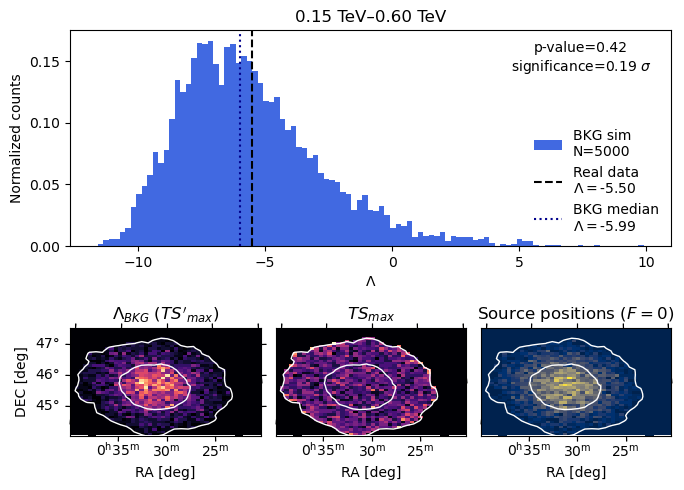

In [25]:
# --- Statistics ---
p_value      = np.mean(lambda_bkg > lambda_real)
significance = norm.ppf(1 - p_value)
lambda_bkg_m = np.median(lambda_bkg)

# --- Sky Maps ---
def _fill_map(geom_image, lon, lat):
    m = Map.from_geom(geom=geom_image)
    m.fill_by_coord({"lon": lon * u.deg, "lat": lat * u.deg})
    return m

map_lambda_bkg = _fill_map(geom_image, lambda_ra_bkg,  lambda_dec_bkg)
map_ts_bkg     = _fill_map(geom_image, tsmax_ra_bkg,   tsmax_dec_bkg)
map_source_sim = _fill_map(geom_image, f_ra_bkg,        f_dec_bkg)
if compute_uls:
    map_ul_bkg = _fill_map(geom_image, ulmax_ra_bkg, ulmax_dec_bkg)

nbins_lambda = 100
min_l_bkg, max_l_bkg = lambda_bkg.min(), lambda_bkg.max()
bins_lambda = np.linspace(min_l_bkg, max_l_bkg, nbins_lambda)

plotting.summary_bkg_simulations(
    geom, bin_edges_ra, bin_edges_dec, data_ligo_2d, threshold_maps,
    lambda_bkg, lambda_real, lambda_bkg_m, p_value, significance,
    map_lambda_bkg, map_ts_bkg, map_source_sim, energy_edges, bins_lambda
)

### Plotting some individual pixel n-on and n-off

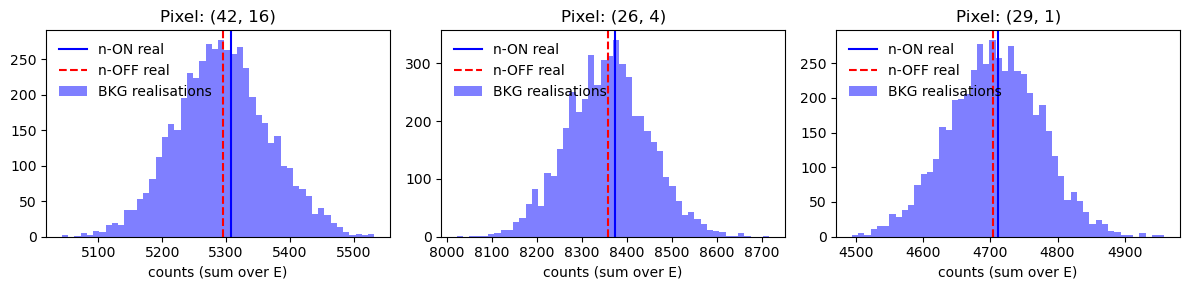

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

for ax in axes:
    random_pixel = (
        np.random.randint(0, bin_edges_ra.shape[0] - 1),
        np.random.randint(0, bin_edges_ra.shape[1] - 1),
    )
    n_on_real = stats_real.n_on.sum(axis=0)[random_pixel]
    n_off_real = stats_real.n_bkg.sum(axis=0)[random_pixel]
    n_on_bkg = [s.n_on.sum(axis=0)[random_pixel] for s in data_bkg["stats"]]

    ax.set_title(f"Pixel: {random_pixel}")
    ax.axvline(n_on_real, color="b", ls="-", label="n-ON real")
    ax.axvline(n_off_real, color="r", ls="--", label="n-OFF real")
    ax.hist(n_on_bkg, 50, color="b", alpha=0.5, label="BKG realisations")
    ax.set_xlabel("counts (sum over E)")
    ax.legend(frameon=False, loc=2)

plt.tight_layout()
plt.show()

# Sending jobs for flux simulations

In [31]:
OVERWRITE_RESULTS = False

In [32]:
# --- Shared Config ---
amplitudes    = np.logspace(-13, -10, 150)
compute_uls_f = False

precision = 0.001
frac_tol  = 0.005

def _results_path(amplitude):
    ext  = "extended" if compute_uls_f else ""
    name = (
        f"{source_name}_{type_obs}_E{e_min.value}_{e_max.value}_bkg{bkg_type}_corr{correlation_radius.value}" + 
        f"{'_isdirac' if USE_DIRAC_DELTA else ''}_binsize{binsz}_N{n_sim_flux}_f{amplitude}_{ext}.npz"
    )
    
    return os.path.join("data", "results", name)

# --- Non-Iterative: Submit Slurm Jobs ---
if not USE_ITERATIVE_ULS:
    for amplitude in amplitudes:
        path_results_f = _results_path(amplitude)
        if os.path.exists(path_results_f) and not OVERWRITE_RESULTS:
            print(f"Amplitude {amplitude:.2e} — already exists, skipping")
            continue
        if os.path.exists(path_results_f):
            print(f"Amplitude {amplitude:.2e} — overwriting")
        _cmd = f"python simulate.py {n_sim_flux} {amplitude} '{path_pkl}' '{path_results_f}' {int(compute_uls_f)}"
        _out     = f"./data/slurm_output/job_simulate_{type_obs}_F{amplitude:.4e}_N{n_sim_flux}.out"
        subprocess.run(f"sbatch -p short --mem=20000 -J simulate_source -o {_out} --wrap='{_cmd}'",
                       shell=True, check=True)

# --- Non-Iterative: Load Results & Compute UL ---
if not USE_ITERATIVE_ULS:
    lambda_f = []
    for amplitude in amplitudes:
        path_results_f = _results_path(amplitude)
        if not os.path.exists(path_results_f):
            print(f"Amplitude {amplitude:.2e} — missing, skipping"); continue
        data_f = np.load(path_results_f, allow_pickle=True)
        lambda_f.append(data_f["lambda_data"])

    # Compute UL as amplitude where median lambda crosses lambda_real
    medians  = np.array([np.median(lf) for lf in lambda_f])
    
    amp_ul   = amplitudes[np.where(medians >= lambda_real)[0][0]]
    data_ul  = np.load(_results_path(amp_ul), allow_pickle=True)
    flux_ul  = data_ul["flux_ul"] if "flux_ul" in data_ul else None
    flux_diff_ul = data_ul["flux_diff_ul"] if "flux_diff_ul" in data_ul else None
    
else:
    _iter_cache = os.path.join("data", "tmp", (
        f"{source_name}_{type_obs}_E{e_min.value}_{e_max.value}_bkg{bkg_type}_corr{correlation_radius.value}" + 
        f"{'_isdirac' if USE_DIRAC_DELTA else ''}_binsize{binsz}" + 
        f"_iterative_nsim{n_sim_flux}_prec{precision}_fractol{frac_tol}.pkl"
    ))

    if os.path.exists(_iter_cache) and not OVERWRITE_RESULTS:
        print("Loading iterative UL cache...")
        with open(_iter_cache, "rb") as f:
            cache = pickle.load(f)
    else:
        cache = simulate.run_iterative_ul(
            path_pkl     = path_pkl,
            lambda_real  = lambda_real,
            lambda_bkg   = lambda_bkg,
            lambda_bkg_m = lambda_bkg_m,
            significance = significance,
            p_value      = p_value,
            energy_edges = energy_edges,
            cl           = confidence_level,
            n_sim        = n_sim_flux,
            precision    = precision,
            frac_tol     = frac_tol,
            amp_lo       = 1e-13,
            amp_hi       = 1e-10,
            max_iter     = 20,
        )
        with open(_iter_cache, "wb") as f:
            pickle.dump(cache, f)
        print(f"Saved iterative UL cache - {_iter_cache}")

    amp_ul       = cache["amp_ul"]
    flux_ul      = cache["flux_ul"]
    flux_diff_ul = cache["flux_diff_ul"]
    amplitudes   = np.array([float(k) for k in cache["lambda_cache"].keys()])
    lambda_f     = [cache["lambda_cache"][k] for k in cache["lambda_cache"]]

Amplitude 1.00e-13 — already exists, skipping
Amplitude 1.05e-13 — already exists, skipping
Amplitude 1.10e-13 — already exists, skipping
Amplitude 1.15e-13 — already exists, skipping
Amplitude 1.20e-13 — already exists, skipping
Amplitude 1.26e-13 — already exists, skipping
Amplitude 1.32e-13 — already exists, skipping
Amplitude 1.38e-13 — already exists, skipping
Amplitude 1.45e-13 — already exists, skipping
Amplitude 1.52e-13 — already exists, skipping
Amplitude 1.59e-13 — already exists, skipping
Amplitude 1.67e-13 — already exists, skipping
Amplitude 1.74e-13 — already exists, skipping
Amplitude 1.83e-13 — already exists, skipping
Amplitude 1.91e-13 — already exists, skipping
Amplitude 2.00e-13 — already exists, skipping
Amplitude 2.10e-13 — already exists, skipping
Amplitude 2.20e-13 — already exists, skipping
Amplitude 2.30e-13 — already exists, skipping
Amplitude 2.41e-13 — already exists, skipping
Amplitude 2.53e-13 — already exists, skipping
Amplitude 2.65e-13 — already exist

In [ ]:
!squeue -u juan.jimenez

### Reading the result `.npz` files

In [34]:
OVERWRITE_RESULTS = True

In [35]:
%%time
cache_file = os.path.join(
    "data", "tmp", (
        f"{source_name}_{type_obs}_E{e_min.value}_{e_max.value}_bkg{bkg_type}_corr{correlation_radius.value}" + 
        f"{'_isdirac' if USE_DIRAC_DELTA else ''}_binsize{binsz}_N{n_sim_flux}_cache.pkl"
))
    
if os.path.exists(cache_file) and not OVERWRITE_RESULTS:
    print(f"Loading cached results...\n")
    with open(cache_file, "rb") as f:
        (
            ra_f, dec_f, lambda_f, lambda_ra_f, lambda_dec_f, ts_dist_f, ts2_dist_f, tsmax_f, tsmax_ra_f, tsmax_dec_f
        ) = pickle.load(f)
else:
    print("Reading and re-agruping data...")
    ra_f, dec_f, lambda_f, lambda_ra_f, lambda_dec_f = [], [], [], [], []
    ts_dist_f, ts2_dist_f, tsmax_f, tsmax_ra_f, tsmax_dec_f = [], [], [], [], []

    # Source amplitudes from iterative cache or SLURM grid
    if USE_ITERATIVE_ULS:
        amplitudes_loop   = np.array([float(k) for k in cache["lambda_cache"].keys()])
        lambda_cache_loop = {float(k): v for k, v in cache["lambda_cache"].items()}
    else:
        amplitudes_loop  = amplitudes
        lambda_cache_loop = None

    for i, amplitude in enumerate(amplitudes_loop):
        print(f"Loading data... {i/len(amplitudes_loop)*100:.2f}%", end="\r")

        if USE_ITERATIVE_ULS:
            # Data already in memory from lambda_cache
            data_lambda  = lambda_cache_loop[amplitude]
            is_inside    = np.ones(len(data_lambda), dtype=bool)  # already filtered
            lambda_f.append(data_lambda[is_inside])
            # No ra/dec/tsmax info in iterative cache — fill with nans
            dummy = np.full(is_inside.sum(), np.nan)
            ra_f.append(dummy); dec_f.append(dummy)
            lambda_ra_f.append(dummy); lambda_dec_f.append(dummy)
            tsmax_f.append(dummy); tsmax_ra_f.append(dummy); tsmax_dec_f.append(dummy)
        else:
            fname_results_f = (
                f"{source_name}_{type_obs}_E{e_min.value}_{e_max.value}_bkg{bkg_type}_corr{correlation_radius.value}" + 
                f"{'_isdirac' if USE_DIRAC_DELTA else ''}_binsize{binsz}_N{n_sim_flux}_f{amplitude}_" + 
                f"{'extended' if bool(compute_uls_f) else ''}.npz"
            )
            
            path_results_f   = os.path.join("data", "results", fname_results_f)
            data = np.load(path_results_f)
            _lambda_ra_f_, _lambda_dec_f_ = -data["f_ra"], data["f_dec"]

            if threshold_maps is not None:
                contour_set = plt.contour(
                    np.rad2deg(ra_grid), np.rad2deg(dec_grid), np.flip(data_ligo_2d, axis=1), levels=[threshold_maps[0]]
                )
                paths = contour_set.get_paths()
                plt.close()
                is_inside = np.array([
                    any(p.contains_point((_lambda_ra_f_[j], _lambda_dec_f_[j])) for p in paths) for j in range(len(_lambda_ra_f_))
                ])
            else:
                is_inside = np.array([
                    mask_threshold_95[
                        np.argmin(np.abs(bin_c_dec[:,0] - data["lambda_dec"][j])),
                        np.argmin(np.abs(bin_c_ra[0,:]  - data["lambda_ra"][j]))
                    ] for j in range(len(data["lambda_dec"]))
                ])

            ra_f.append(_lambda_ra_f_[is_inside]);        dec_f.append(_lambda_dec_f_[is_inside])
            lambda_f.append(data["lambda_data"][is_inside])
            lambda_ra_f.append(data["lambda_ra"][is_inside]); lambda_dec_f.append(data["lambda_dec"][is_inside])
            tsmax_f.append(data["tsmax"][is_inside])
            tsmax_ra_f.append(data["tsmax_ra"][is_inside]); tsmax_dec_f.append(data["tsmax_dec"][is_inside])

    # Consistent name
    amplitudes = amplitudes_loop

    print()
    with open(cache_file, "wb") as f:
        pickle.dump(
            (ra_f, dec_f, lambda_f, lambda_ra_f, lambda_dec_f, ts_dist_f, ts2_dist_f, tsmax_f, tsmax_ra_f, tsmax_dec_f),
            f
        )

Reading and re-agruping data...
Loading data... 99.33%
CPU times: user 35.9 s, sys: 11.6 s, total: 47.5 s
Wall time: 50.9 s


#### Plotting all the distributions

In [36]:
if not USE_ITERATIVE_ULS:
    log_amplitudes = np.log10(amplitudes)
    log_edges_inner = (log_amplitudes[1:] + log_amplitudes[:-1]) / 2
    amplitude_edges_inner = 10**log_edges_inner
    
    first_edge = 10**(2*log_amplitudes[0] - log_edges_inner[0])
    last_edge = 10**(2*log_amplitudes[-1] - log_edges_inner[-1])
    
    amplitude_edges = np.concatenate([[first_edge], amplitude_edges_inner, [last_edge]])
    
    delta_l_bkg = max_l_bkg - min_l_bkg
    lambda_bins = np.linspace(min_l_bkg - delta_l_bkg * 0.1, max_l_bkg  +  delta_l_bkg * 1.5, 200)
    lambda_bins_ext = np.linspace(min_l_bkg - delta_l_bkg * 0.1, max_l_bkg  +  delta_l_bkg * 1.5, 200)
    lambda_bins_c = (lambda_bins[1:] + lambda_bins[:-1]) / 2
    
    lambda_hist_bkg = np.histogram(lambda_bkg, lambda_bins, density=False)[0]
    lambda_hist_f   = np.array([np.histogram(l, lambda_bins, density=False)[0] for l in lambda_f])

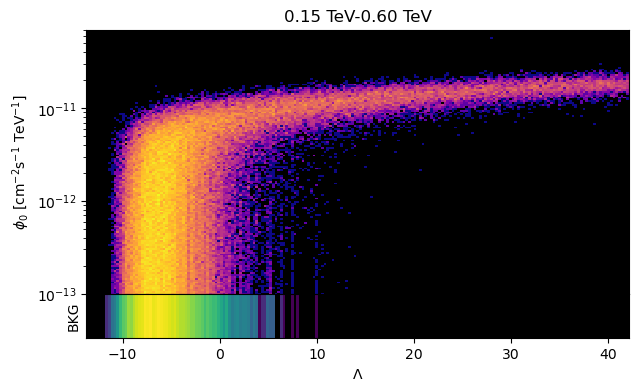

In [37]:
if not USE_ITERATIVE_ULS:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 4), gridspec_kw={"height_ratios": [6, 1]}, sharex=True)

    pc1 = ax1.pcolormesh(lambda_bins, amplitude_edges, lambda_hist_f, norm=LogNorm(), cmap="plasma")
    pc2 = ax2.pcolormesh(lambda_bins, [0, 1], [lambda_hist_bkg], norm=LogNorm(), cmap="viridis")
    
    for ax in [ax1, ax2]:
        ax.set_facecolor("k")
    ax1.set_ylim(1e-13, 7e-11); ax1.set_yscale("log"); ax2.set_yticks([])
    ax2.set_ylabel(f"BKG"); ax2.set_xlabel("$\\Lambda$"); ax1.set_ylabel("$\\phi_0$ [cm${}^{-2}$s${}^{-1}$ TeV${}^{-1}$]")
    ax1.set_title(f"{energy_edges[0]:.2f}-{energy_edges[1]:.2f}"); plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()

## Computing sensitivity + ULs
First we set the confidence level of the limits selection.

Then we can find the ULs fitting the curves to a sigmoid but usually does not fit very well so we just check where the curve hits the turning point.

In [38]:
if not USE_ITERATIVE_ULS:
    lambda_f_m = np.array([np.percentile(l, 50) for l in lambda_f])
    
    # The fraction of lambdas simulated larger than the data or the BKG of lambda
    lambda_f_frac_bkg  = np.array([np.sum(l > lambda_bkg_m) / len(l) for l in lambda_f])
    lambda_f_frac_real = np.array([np.sum(l > lambda_real)  / len(l) for l in lambda_f])
    
    # Fitting a sigmoid to the fraction of lambdas
    x_bkg, y_bkg = np.log10(amplitudes), lambda_f_frac_bkg
    popt_bkg, pcov_bkg   = curve_fit(
        utils.sigmoid, x_bkg, y_bkg, p0=[max(y_bkg), np.median(x_bkg), 1, min(y_bkg)]
    )
    x_real, y_real = np.log10(amplitudes), lambda_f_frac_real
    popt_real, pcov_real = curve_fit(
        utils.sigmoid, x_real, y_real, p0=[max(y_real), np.median(x_real), 1, min(y_real)]
    )
    
    # amplitude95_bkg  = 10 ** utils.find_x_at_y(confidence_level, popt_bkg)
    # amplitude95_real = 10 ** utils.find_x_at_y(confidence_level, popt_real)
    
    # We check manually where the threshold point is
    amplitude95_bkg  = utils.find_amplitude_at_cl(np.log10(amplitudes), lambda_f_frac_bkg, cl=confidence_level)
    amplitude95_real = utils.find_amplitude_at_cl(np.log10(amplitudes), lambda_f_frac_real, cl=confidence_level)
    
    idx_f_bkg  = np.abs(amplitudes - amplitude95_bkg).argmin()
    idx_f_real = np.abs(amplitudes - amplitude95_real).argmin()

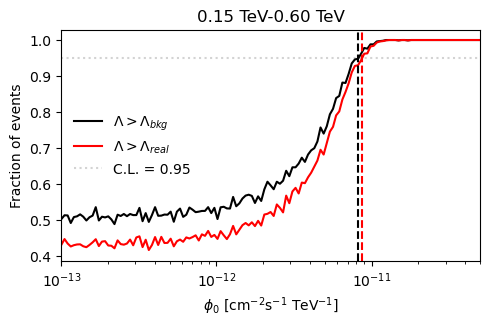

In [39]:
if not USE_ITERATIVE_ULS:
    fig, ax = plt.subplots(1, 1, figsize=(5.4, 3))
    ax.plot(amplitudes, lambda_f_frac_bkg,  color="k", label="$\\Lambda>\\Lambda_{bkg}$")
    ax.plot(amplitudes, lambda_f_frac_real, color="r", label="$\\Lambda>\\Lambda_{real}$")
    ax.axvline(amplitude95_bkg,  color="k", ls="--")
    ax.axvline(amplitude95_real, color="r", ls="--")
    ax.axhline(confidence_level, ls=":", color="lightgray", zorder=-2, label=f"C.L. = {confidence_level}")
    ax.legend(frameon=False)
    ax.set_xlabel("$\\phi_0$ [cm${}^{-2}$s${}^{-1}$ TeV${}^{-1}$]")
    ax.set_ylabel("Fraction of events")
    ax.set_title(f"{energy_edges[0]:.2f}-{energy_edges[1]:.2f}")
    ax.set_xlim(1e-13, 5e-11); ax.set_xscale("log")
    plt.show()
else:

    hist_frac = cache["hist_frac"]
    hist_amp  = cache["hist_amp"]
    iters     = range(1, len(hist_frac) + 1)

    fig, ax1 = plt.subplots(figsize=(6, 3.5))
    ax2 = ax1.twinx()

    # ---- Amplitude trace (background axis) ----
    ax2.plot(iters, hist_amp, color="steelblue", lw=1.4, ls="--",
             marker="s", ms=4, alpha=0.7, label="Amplitude")
    ax2.set_ylabel(r"Tested $\phi_0$ [cm$^{-2}$s$^{-1}$ TeV$^{-1}$]",
                   color="steelblue", fontsize=9)
    ax2.tick_params(axis="y", labelcolor="steelblue")
    ax2.set_yscale("log")

    # ---- Fraction trace (foreground axis) ----
    ax1.plot(iters, hist_frac, "ko-", ms=5, lw=1.6, zorder=3, label="Fraction")
    ax1.axhline(confidence_level, color="r", ls="--", lw=1.5,
                label=f"CL = {confidence_level}")
    ax1.axhspan(confidence_level - 0.02, confidence_level + 0.02,
                alpha=0.12, color="r", zorder=0)

    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("Fraction > target")
    ax1.set_xticks(list(iters))
    ax1.set_title(f"Iterative UL convergence  —  UL = {amp_ul:.3e}")
    ax1.set_zorder(ax2.get_zorder() + 1)
    ax1.patch.set_visible(False)

    # ---- Combined legend ----
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False,
               fontsize=8)

    
    fig.tight_layout()
    plt.show()

# Summary of results:

In [40]:
def _pwl_fluxes(amplitude, energy_edges):
    pwl = PowerLawSpectralModel(amplitude=amplitude * u.Unit("TeV-1 s-1 cm-2"), index=2)
    return pwl.integral(*energy_edges), pwl.energy_flux(*energy_edges).to(u.erg / (u.s * u.cm**2))

print(f"Analysis of {type_obs} data in Energies {energy_edges[0]:.2f}-{energy_edges[1]:.2f}")
print(f"Significance of observations: {significance:.2f}σ\n")

if not USE_ITERATIVE_ULS:
    flux_bkg,  flux_diff_bkg  = _pwl_fluxes(amplitude95_bkg,  energy_edges)
    flux_real, flux_diff_real = _pwl_fluxes(amplitude95_real, energy_edges)

    # Sensitivity: based on BKG median crossing; UL: based on real data crossing
    col_sens = "33" if significance >= 0.0 else "32"
    col_ul   = "32" if significance >= 0.0 else "31"
    final_f_ul = flux_real if significance >= 0.0 else flux_bkg

    print(f"\033[{col_sens}mSensitivity:  phi0={amplitude95_bkg:.2e}  "
          f"Flux={flux_bkg:.2e}  dFlux={flux_diff_bkg:.2e}\033[0m")
    print(f"\033[{col_ul}mUpper Limit:  phi0={amplitude95_real:.2e}  "
          f"Flux={flux_real:.2e}  dFlux={flux_diff_real:.2e}\033[0m")

else:
    # Iterative mode: only a single UL is computed, no sensitivity
    flux_real, flux_diff_real = flux_ul, flux_diff_ul
    final_f_ul = flux_real

    print(f"\033[32mUpper Limit:  phi0={amp_ul:.2e}  "
          f"Flux={flux_real:.2e}  dFlux={flux_diff_real:.2e}\033[0m")

flux_ul_95_max = np.nanmax(flux_uls_95)
flux_ul_max = np.nanmax(flux_uls)
final_f_ul_val = final_f_ul.value if hasattr(final_f_ul, "value") else float(final_f_ul)
print(f"\nUL vs sky-map 95% max: {final_f_ul_val:.3e} vs {flux_ul_95_max:.3e}  "
      f"({(final_f_ul_val - flux_ul_95_max) / flux_ul_95_max * 100:+.1f}%)")
print(f"UL vs sky-map max:     {final_f_ul_val:.3e} vs {flux_ul_max:.3e}  "
      f"({(final_f_ul_val - flux_ul_max) / flux_ul_max * 100:+.1f}%)")

Analysis of mono data in Energies 0.15 TeV-0.60 TeV
Significance of observations: 0.19σ

Sensitivity:  phi0=8.24e-12  Flux=4.12e-11 1 / (s cm2)  dFlux=1.83e-11 erg / (s cm2)
Upper Limit:  phi0=8.70e-12  Flux=4.35e-11 1 / (s cm2)  dFlux=1.93e-11 erg / (s cm2)

UL vs sky-map 95% max: 4.352e-11 vs 7.000e-11  (-37.8%)
UL vs sky-map max:     4.352e-11 vs 7.000e-11  (-37.8%)


### Showing the threshold simulated case

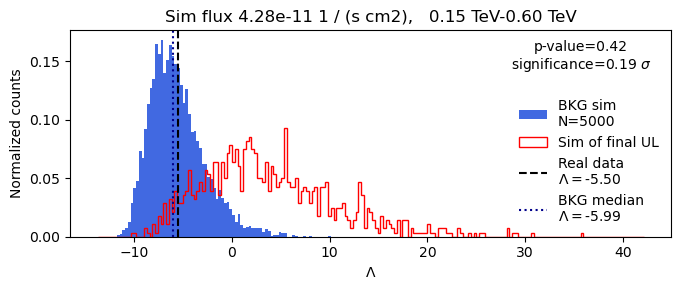

In [41]:
if not USE_ITERATIVE_ULS:
    fig, axt = plt.subplots(1, 1, figsize=(7, 3))
    
    axt.hist(lambda_bkg, lambda_bins, color="royalblue", 
             density=True, histtype="stepfilled", label=f"BKG sim\nN={len(lambda_bkg)}")
    axt.hist(lambda_f[idx_f_bkg if significance < 0 else idx_f_real], 
             lambda_bins_ext, color="r", density=True, histtype="step", label=f"Sim of final UL")
    
    axt.text(
        0.85, 0.87, f"p-value={p_value:.2f}\nsignificance={significance:.2f} $\\sigma$",
        ha="center", va="center", transform=axt.transAxes
    )
    axt.axvline(lambda_real, color="k", ls="--", label=f"Real data\n$\\Lambda=${lambda_real:.2f}")
    axt.axvline(lambda_bkg_m, color="darkblue", ls=":", label=f"BKG median\n$\\Lambda=${lambda_bkg_m:.2f}")
    
    axt.legend(frameon=False, loc=4)
    axt.set_xlabel("$\\Lambda$"); axt.set_ylabel("Normalized counts")
    
    pwl_sim = PowerLawSpectralModel(
        amplitude=amplitudes[idx_f_bkg if significance < 0 else idx_f_real] * u.Unit("TeV-1 s-1 cm-2"), index=2
    )
    flux_sim = pwl_sim.integral(*energy_edges)
    
    axt.set_title(f"Sim flux {flux_sim:.2e},   {energy_edges[0]:.2f}-{energy_edges[1]:.2f}")
    fig.tight_layout()
    
    plt.show()

### Showing the ULs in front of the real distributions

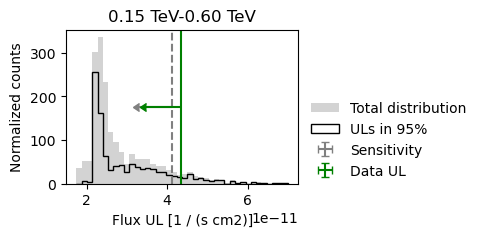

In [42]:
fig, ax = plt.subplots(figsize=(3, 2))
mask = ~np.isnan(flux_uls_95)
single_pixel = np.sum(mask) == 1

h = ax.hist(flux_uls, 40, histtype="stepfilled", color="lightgray", label="Total distribution")
if single_pixel:
    ax.axvline(flux_uls_95[mask][0], color="k", lw=1, label="ULs in 95%")
else:
    ax.hist(flux_uls_95, h[1], histtype="step", color="k", label="ULs in 95%")

ymid = np.diff(ax.get_ylim())[0] / 2

if not USE_ITERATIVE_ULS:
    if significance >= 0.0:
        col_sens, col_ul = "0.5", "green"
        lab_sens, lab_ul = "Sensitivity", "Data UL"
        ls_sens,  ls_ul  = "--", "-"
    else:
        col_sens, col_ul = "green", "0.5"
        lab_sens, lab_ul = "Data UL", "Overestimated UL"
        ls_sens,  ls_ul  = "-", "--"
    for val, ls, col, lab in [(flux_bkg.value, ls_sens, col_sens, lab_sens),
                              (flux_real.value, ls_ul,  col_ul,  lab_ul)]:
        ax.axvline(val, ls=ls, color=col)
        ax.errorbar(val, ymid, yerr=0, xerr=val*0.2, xuplims=True, ls="", color=col, label=lab)
else:
    val = flux_real.value if hasattr(flux_real, "value") else float(flux_real)
    ax.axvline(val, ls="-", color="green")
    ax.errorbar(val, ymid, yerr=0, xerr=val*0.2, xuplims=True, ls="", color="green", label="Flux UL")

ax.set_xlabel("Flux UL [1 / (s cm2)]"); ax.set_ylabel("Normalized counts")
ax.set_title(f"{energy_edges[0]:.2f}-{energy_edges[1]:.2f}")
ax.legend(frameon=False, loc=(1.03, 0))
plt.show()

### Showing UL distributions in the simulations

In [43]:
if compute_uls and not USE_ITERATIVE_ULS:
    
    fig, ax = plt.subplots(figsize=(5, 3))
    
    ax.hist(ulmax_bkg, 25, density=True, 
            histtype="stepfilled", color="royalblue", label="Maximum UL in 95%", zorder=-5)
    
#     ax.hist(flux_uls, 50, density=True, histtype="step", ls=":", color="k", label="Real Data", zorder=10)
    ax.hist(flux_uls_95, 40, density=True, histtype="step", color="k", label="Real Data 95%", zorder=10)
    
    for data in ul_dist:
        data_95 = np.where(mask_threshold_95, data, np.nan).ravel()
        ax.hist(data_95, 40, density=True, histtype="step", color="0.5", alpha=0.2, zorder=0)
    
    flux_ul = flux_bkg if significance < 0 else flux_real
    ax.axvline(flux_ul.value, ls="-", color="crimson")
    ax.errorbar(flux_ul.value, np.diff(ax.get_ylim())[0]/2, yerr=0, 
        xerr=flux_ul.value*0.4, xuplims=True, ls="", color="crimson", label="Global UL")
    ax.plot([], [], color="gray", ls="-", marker="", 
            label="Simulation\ndistributions 95%")

    
    ax.set_title(f"{energy_edges[0]:.2f}-{energy_edges[1]:.2f}")
    
    ax.legend(loc=(1.03, 0), frameon=False)
    ax.set_xlabel("Flux UL [1 / (s cm2)]"); ax.set_ylabel("Normalized counts")
    
    plt.show()

In [44]:
if compute_uls and not USE_ITERATIVE_ULS:
    
    fig, ax = plt.subplots(figsize=(5, 3))
    
    ax.hist(lambda_bkg, 30, density=True, 
            histtype="stepfilled", color="r", label="$\\Lambda$ (max TS')", zorder=-5)
    ts2_masked = np.where(mask_threshold_95, ts2, np.nan).ravel()
    ax.hist(ts2_masked, 30, density=True, histtype="step", color="k", label="Real Data", zorder=10)
    for data in ts2_dist:
        data = np.where(mask_threshold_95, data, np.nan).ravel()
        ax.hist(data, 30, density=True, histtype="step", color="0.5", alpha=0.2, zorder=0)
    
    ax.set_title(f"{energy_edges[0]:.2f}-{energy_edges[1]:.2f}")
    ax.plot([], [], color="0.8", label="Simulated data")
    
    plt.legend(loc=(1.03, 0), frameon=False)
    ax.set_xlabel("TS'"); ax.set_ylabel("Normalized counts")
    ax.set_title(f"{energy_edges[0]:.2f}-{energy_edges[1]:.2f}")
    plt.show()